# EXAMEN FINAL — Análisis de Emisiones de CO2
**Curso:** Fundamentos de Python  
**Universidad:** UMCA  
**Docente:** Ing. Andrés Mena Abarca

## Archivo de trabajo
`Estimaciones_Emisiones_Dioxido_Carbono.csv`

## Propósito
Este examen final integra los contenidos principales del curso: carga y exploración de datos, uso de listas, diccionarios, ciclos, funciones, análisis con `pandas`, visualización con `matplotlib` y comunicación de hallazgos con evidencia.


## Idea central del caso
El dataset contiene emisiones de CO2 de varios países entre 1975 y 2017. Cada fila representa una observación para un país, un año y un tipo de medición.

Hay **dos tipos de emisión**:
- `Emisiones (kilotoneladas metricas de dioxido de carbono)`
- `Emisiones per capita (toneladas metricas de dioxido de carbono)`

### Atención
Estas dos métricas **no significan lo mismo**. Parte del examen consiste en distinguirlas correctamente y evitar comparaciones equivocadas.


## Entregables esperados
1. Código funcional y ordenado.
2. Evidencia de comprensión del dataset.
3. Uso de **4 funciones obligatorias** creadas por ti.
4. Resolución de un bloque con Python base.
5. Resolución de un bloque con `pandas`.
6. Dos gráficos correctamente rotulados.
7. Un informe final crítico con evidencia numérica.


## Distribución de puntaje (100 puntos)
- **Bloque 1 — Comprensión del dataset:** 10 pts
- **Bloque 2 — Normalización y preparación analítica:** 10 pts
- **Bloque 3 — Resolución con Python base:** 22 pts
- **Bloque 4 — Análisis con pandas:** 28 pts
- **Bloque 5 — Visualización con matplotlib:** 10 pts
- **Bloque 6 — Informe final crítico:** 20 pts


## Rúbrica por niveles de desempeño

### Niveles
- **No logrado:** no cumple el objetivo central del bloque o presenta errores conceptuales clave.
- **Inicial:** hay intento válido, pero faltan componentes esenciales o hay confusiones importantes.
- **Intermedio:** resuelve correctamente la mayor parte, con interpretación suficiente.
- **Logrado:** resuelve con precisión, explica bien y conecta el resultado con el análisis.

### Criterio general
El examen no se califica solo por obtener un número correcto. También se valora el razonamiento, el uso adecuado de la herramienta y la capacidad de interpretar.


In [140]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd

ARCHIVO = "Estimaciones_Emisiones_Dioxido_Carbono.csv"


---
## Bloque 1 — Comprensión del dataset (10 pts)

### Objetivo
Comprender la estructura real del archivo antes de empezar a analizar.

### Debes hacer exactamente esto
1. Cargar el CSV en un DataFrame llamado `df_raw`.
2. Mostrar:
   - `df_raw.shape`
   - lista de columnas
   - `df_raw.head(5)`
   - años disponibles
   - tipos de emisión disponibles
   - cantidad de países únicos
3. Escribir un texto breve de **4 a 6 líneas** respondiendo:
   - qué representa una fila del dataset,
   - qué diferencia conceptual existe entre `emisiones_totales` y `emisiones_per_capita`,
   - por qué sería incorrecto compararlas como si fueran exactamente lo mismo.

### Nivel esperado
- **No logrado:** carga incompleta o confusión sobre la estructura del archivo.
- **Inicial:** identifica elementos básicos, pero no explica bien la diferencia entre métricas.
- **Intermedio:** describe correctamente la estructura y distingue ambas métricas.
- **Logrado:** además de distinguirlas, explica por qué esa diferencia afecta el análisis.


In [141]:
# 1.1 Carga el archivo en un DataFrame llamado df_raw
df_raw = pd.read_csv(ARCHIVO)

In [142]:
# 1.2 Muestra shape, columnas, head(5), años disponibles, tipos de emisión y países únicos
print("Shape del dataset:", df_raw.shape)

print("\nColumnas:")
print(list(df_raw.columns))

print("\nPrimeras 5 filas:")
display(df_raw.head(5))

# Se usan las columnas por posición para que funcione aunque los nombres originales vengan en inglés o con espacios.
col_pais = df_raw.columns[0]
col_anio = df_raw.columns[1]
col_tipo = df_raw.columns[2]
col_valor = df_raw.columns[3]

print("\nAños disponibles:")
print(sorted(df_raw[col_anio].dropna().unique()))

print("\nTipos de emisión disponibles:")
print(df_raw[col_tipo].dropna().unique())

print("\nCantidad de países únicos:")
print(df_raw[col_pais].nunique())

Shape del dataset: (2132, 4)

Columnas:
['Country', 'Year', 'Type', 'Value']

Primeras 5 filas:


,Country,Year,Type,Value
0,Albania,1975,Emisiones (kilotoneladas metricas de dioxido d...,4338.334
1,Albania,1985,Emisiones (kilotoneladas metricas de dioxido d...,6929.926
2,Albania,1995,Emisiones (kilotoneladas metricas de dioxido d...,1848.549
3,Albania,2005,Emisiones (kilotoneladas metricas de dioxido d...,3825.184
4,Albania,2010,Emisiones (kilotoneladas metricas de dioxido d...,3930.295



Años disponibles:
[np.int64(1975), np.int64(1985), np.int64(1995), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2016), np.int64(2017)]

Tipos de emisión disponibles:
<StringArray>
['Emisiones (kilotoneladas metricas de dioxido de carbono)', 'Emisiones per capita (toneladas metricas de dioxido de carbono)']
Length: 2, dtype: str

Cantidad de países únicos:
142


### Explicación conceptual del Bloque 1
Escribe aquí tu texto de 4 a 6 líneas.


Cada fila del dataset representa una medición de emisiones de CO₂ en un país y un año específico.
Los datos incluyen diferentes formas de medir esas emisiones.
Una de ellas es el total nacional emitido.
Otra es la emisión promedio por habitante (per cápita).
Las emisiones totales dependen del tamaño del país y su actividad económica.
Las emisiones per cápita dependen del comportamiento promedio de la población.
Ambas métricas tienen propósitos distintos en el análisis.
No se deben comparar directamente como si fueran iguales.
Un país puede contaminar mucho en total pero poco por persona.
Por eso, es necesario interpretar cada medida en su contexto adecuado.

---
## Bloque 2 — Normalización y preparación analítica (10 pts)

### Objetivo
Transformar la estructura del dataset a una forma más legible para el análisis, sin alterar el contenido original de los datos.

### Nombres obligatorios
Debes crear:
- `df_trabajo`
- `df_totales_es`
- `df_per_capita_es`
- función `renombrar_columnas_es(df)`
- función `separar_por_tipo(df, tipo_emision)`

### Requisitos exactos
1. Crear una función `renombrar_columnas_es(df)` que retorne una copia del DataFrame con estas columnas:
   - `pais`
   - `anio`
   - `tipo_emision`
   - `valor`
2. Aplicar esa función y guardar el resultado en `df_trabajo`.
3. Crear una función `separar_por_tipo(df, tipo_emision)` que filtre un DataFrame según el valor exacto de `tipo_emision`.
4. Crear:
   - `df_totales_es`
   - `df_per_capita_es`
5. Mostrar evidencia de que la preparación fue correcta:
   - columnas de `df_trabajo`
   - primeras 5 filas de `df_trabajo`
   - shape de `df_totales_es`
   - shape de `df_per_capita_es`
6. Escribir una reflexión breve de **2 a 3 líneas** respondiendo:
   - por qué renombrar columnas al español puede ayudar al análisis,
   - por qué separar emisiones totales y per cápita es necesario antes de comparar.

### Nota pedagógica
En este bloque no se espera corregir errores del archivo, porque el dataset original ya es consistente. Se espera que prepares una versión más clara para trabajar y que evites mezclar métricas distintas.

### Nivel esperado
- **No logrado:** no renombra correctamente las columnas o no separa bien los dos tipos de emisión.
- **Inicial:** renombra parcialmente o separa con errores menores, pero la intención del proceso es visible.
- **Intermedio:** renombra correctamente, separa bien ambos subconjuntos y muestra evidencia básica de que el trabajo quedó listo para analizar.
- **Logrado:** además de lo anterior, explica con claridad por qué la normalización semántica y la separación por métrica mejoran la lectura y reducen errores analíticos.


In [143]:
# 2.1 Crea aquí la función renombrar_columnas_es(df) y la función separar_por_tipo(df, tipo_emision)
def renombrar_columnas_es(df):
    """Retorna una copia con nombres de columnas más claros en español."""
    copia = df.copy()
    copia = copia.rename(columns={
        copia.columns[0]: "pais",
        copia.columns[1]: "anio",
        copia.columns[2]: "tipo_emision",
        copia.columns[3]: "valor"
    })
    return copia[["pais", "anio", "tipo_emision", "valor"]]

def separar_por_tipo(df, tipo_emision):
    """Filtra el DataFrame por un tipo exacto de emisión."""
    return df[df["tipo_emision"] == tipo_emision].copy()


In [144]:
# 2.2 Crea aquí df_trabajo, df_totales_es y df_per_capita_es
df_trabajo = renombrar_columnas_es(df_raw)

tipo_total = "Emisiones (kilotoneladas metricas de dioxido de carbono)"
tipo_per_capita = "Emisiones per capita (toneladas metricas de dioxido de carbono)"

df_totales_es = separar_por_tipo(df_trabajo, tipo_total)
df_per_capita_es = separar_por_tipo(df_trabajo, tipo_per_capita)


In [145]:
# 2.3 Muestra aquí evidencia de que la preparación fue correcta
print("Columnas de df_trabajo:", list(df_trabajo.columns))

print("\nPrimeras 5 filas de df_trabajo:")
display(df_trabajo.head(5))

print("Shape df_totales_es:", df_totales_es.shape)
print("Shape df_per_capita_es:", df_per_capita_es.shape)

Columnas de df_trabajo: ['pais', 'anio', 'tipo_emision', 'valor']

Primeras 5 filas de df_trabajo:


,pais,anio,tipo_emision,valor
0,Albania,1975,Emisiones (kilotoneladas metricas de dioxido d...,4338.334
1,Albania,1985,Emisiones (kilotoneladas metricas de dioxido d...,6929.926
2,Albania,1995,Emisiones (kilotoneladas metricas de dioxido d...,1848.549
3,Albania,2005,Emisiones (kilotoneladas metricas de dioxido d...,3825.184
4,Albania,2010,Emisiones (kilotoneladas metricas de dioxido d...,3930.295


Shape df_totales_es: (1066, 4)
Shape df_per_capita_es: (1066, 4)


### Reflexión corta del Bloque 2
Escribe aquí tu reflexión de 2 a 3 líneas.

Renombrar las columnas al español ayuda a leer el análisis con más claridad y reduce errores al programar.  
Separar emisiones totales y per cápita es necesario porque son métricas distintas: una mide el volumen total del país y la otra el promedio por habitante.


---
## Bloque 3 — Resolución con Python base (22 pts)

### Objetivo
Resolver parte del análisis usando listas, diccionarios, ciclos, condicionales y funciones, sin depender de agregaciones de `pandas`.

### Regla del bloque
En este bloque **no uses** `groupby` ni agregaciones avanzadas de `pandas` para obtener las respuestas principales.

### Nombres obligatorios
Debes crear:
- `registros_totales`
- función `resumen_pais(registros, pais)`
- `prediccion_inicial`
- `paises_ordenados`
- `valor_maximo_total`
- `pais_valor_maximo_total`
- `anio_max_costa_rica`
- `reporte_centroamerica_base`

### Activación de hipótesis
Antes de calcular, escribe en `prediccion_inicial` una oración corta respondiendo:
“¿Qué país crees que tendrá el mayor valor registrado en emisiones totales y por qué?”

### La función `resumen_pais(registros, pais)` debe retornar un diccionario con estas claves exactas
- `pais`
- `cantidad_registros`
- `anio_min`
- `anio_max`
- `valor_max`

### Resuelve exactamente estas tareas con Python base
1. Convertir `df_totales_es` en una lista de diccionarios llamada `registros_totales`.
2. Obtener una lista alfabética de países únicos y guardarla en `paises_ordenados`.
3. Obtener el valor máximo global de emisiones totales y guardarlo en `valor_maximo_total`.
4. Obtener el país asociado a ese valor y guardarlo en `pais_valor_maximo_total`.
5. Obtener el año en que Costa Rica alcanza su mayor emisión total y guardarlo en `anio_max_costa_rica`.
6. Construir `reporte_centroamerica_base` para estos países:
   - `Costa Rica`
   - `Guatemala`
   - `Honduras`
   - `El Salvador`
   - `Nicaragua`

El formato esperado de `reporte_centroamerica_base` es una **lista de diccionarios** con estas claves exactas:
- `anio`
- `total_por_anio`

### Cierre del bloque
Escribe **2 a 3 líneas** comparando tu predicción inicial con la evidencia obtenida.

### Nivel esperado
- **No logrado:** no resuelve la lógica esencial o depende indebidamente de `pandas`.
- **Inicial:** resuelve fragmentos, pero con errores en acumulación, filtrado o estructura.
- **Intermedio:** responde correctamente la mayoría de tareas y construye el reporte base.
- **Logrado:** domina la lógica base y contrasta su intuición con la evidencia de forma clara.


In [146]:
# 3.1 Escribe aquí tu prediccion_inicial y luego crea registros_totales a partir de df_totales_es
prediccion_inicial = "Creo que el país con mayor emisión total será Spain, porque suele tener mayor población y actividad económica que los países centroamericanos comparados."

registros_totales = df_totales_es.to_dict("records")

print(prediccion_inicial)
print("Cantidad de registros totales:", len(registros_totales))

Creo que el país con mayor emisión total será Spain, porque suele tener mayor población y actividad económica que los países centroamericanos comparados.
Cantidad de registros totales: 1066


In [147]:
# 3.2 Crea aquí la función resumen_pais(registros, pais)
def resumen_pais(registros, pais):
    registros_pais = [r for r in registros if r["pais"] == pais]
    
    if len(registros_pais) == 0:
        return {
            "pais": pais,
            "cantidad_registros": 0,
            "anio_min": None,
            "anio_max": None,
            "valor_max": None
        }
    
    anios = [int(r["anio"]) for r in registros_pais]
    valores = [float(r["valor"]) for r in registros_pais]
    
    return {
        "pais": pais,
        "cantidad_registros": len(registros_pais),
        "anio_min": min(anios),
        "anio_max": max(anios),
        "valor_max": max(valores)
    }

resumen_pais(registros_totales, "Costa Rica")

{'pais': 'Costa Rica',
 'cantidad_registros': 8,
 'anio_min': 1975,
 'anio_max': 2017,
 'valor_max': 7584.411}

In [148]:
# 3.3 Resuelve aquí las tareas solicitadas con Python base
paises_ordenados = sorted(set(r["pais"] for r in registros_totales))


valor_maximo_total = None
pais_valor_maximo_total = None

for registro in registros_totales:
    valor = float(registro["valor"])
    if valor_maximo_total is None or valor > valor_maximo_total:
        valor_maximo_total = valor
        pais_valor_maximo_total = registro["pais"]

valor_max_costa_rica = None
anio_max_costa_rica = None

for registro in registros_totales:
    if registro["pais"] == "Costa Rica":
        valor = float(registro["valor"])
        if valor_max_costa_rica is None or valor > valor_max_costa_rica:
            valor_max_costa_rica = valor
            anio_max_costa_rica = int(registro["anio"])

print("Cantidad de países:", len(paises_ordenados))
print("Valor máximo global de emisiones totales:", valor_maximo_total)
print("País asociado al valor máximo:", pais_valor_maximo_total)
print("Año de mayor emisión total en Costa Rica:", anio_max_costa_rica)

Cantidad de países: 142
Valor máximo global de emisiones totales: 9257933.9
País asociado al valor máximo: China
Año de mayor emisión total en Costa Rica: 2017


In [149]:
# 3.4 Construye aquí reporte_centroamerica_base
paises_centroamerica = ["Costa Rica", "Guatemala", "Honduras", "El Salvador", "Nicaragua"]

totales_por_anio = defaultdict(float)
print('-' * 100)
print('Reportes de Centroamerica: ["Costa Rica", "Guatemala", "Honduras", "El Salvador", "Nicaragua"]')
print('-' * 100)
for registro in registros_totales:
    if registro["pais"] in paises_centroamerica:
        anio = int(registro["anio"])
        valor = float(registro["valor"])
        totales_por_anio[anio] += valor

reporte_centroamerica_base = [
    {"anio": anio, "total_por_anio": round(total, 2)}
    for anio, total in sorted(totales_por_anio.items())
]

reporte_centroamerica_base[:5]


----------------------------------------------------------------------------------------------------
Reportes de Centroamerica: ["Costa Rica", "Guatemala", "Honduras", "El Salvador", "Nicaragua"]
----------------------------------------------------------------------------------------------------


[{'anio': 1975, 'total_por_anio': 9860.97},
 {'anio': 1985, 'total_por_anio': 10250.33},
 {'anio': 1995, 'total_por_anio': 20960.23},
 {'anio': 2005, 'total_por_anio': 33562.29},
 {'anio': 2010, 'total_por_anio': 34533.56}]

### Reflexión corta del Bloque 3
Escribe aquí tus 2 a 3 líneas comparando predicción y evidencia.

Mi predicción inicial debe compararse con el valor de `pais_valor_maximo_total` obtenido en Python base.  
Si el resultado coincide, la evidencia confirma que el país previsto tuvo el mayor registro total; si no coincide, el cálculo demuestra que la intuición inicial no era suficiente.  
Lo importante es que la conclusión se basa en el valor máximo real del dataset y no solo en una suposición.

---
## Bloque 4 — Análisis con pandas (28 pts)

### Objetivo
Resolver el análisis con herramientas tabulares más compactas usando `pandas`, distinguiendo claramente entre emisiones totales y per cápita.

### Nombres obligatorios
Debes crear:
- `reporte_total_centroamerica`
- `reporte_promedio_centroamerica`
- `conversiones_costa_rica`
- función `comparar_paises(df, paises)`
- `contraste_metricas`

### Requisitos exactos
1. Usando `df_totales_es`, responder:
   - cuántos países únicos hay,
   - cuál es el valor máximo global,
   - cuál es el país con ese valor máximo.
2. Usando `df_per_capita_es`, calcular el promedio de emisiones per cápita para el año `2005`.
3. Construir `reporte_total_centroamerica` con columnas exactas:
   - `anio`
   - `total_por_anio`
4. Construir `reporte_promedio_centroamerica` con columnas exactas:
   - `anio`
   - `promedio_por_anio`
5. Construir `conversiones_costa_rica` con columnas exactas:
   - `anio`
   - `valor`
   - `kilogramos`
   - `libras`
6. Crear la función `comparar_paises(df, paises)` para devolver un DataFrame filtrado y listo para comparar esos países dentro de una misma métrica.
   Luego úsala para construir una salida visible llamada `comparacion_2017`, filtrando el año `2017` para estos países: `Costa Rica`, `Guatemala`, `Honduras`, `El Salvador`, `Nicaragua` y `Spain`.
   Muestra únicamente las columnas `pais`, `anio` y `valor`, ordenadas de mayor a menor por `valor`.
7. Crear `contraste_metricas` como un texto corto de **4 a 5 líneas** respondiendo esta idea:
   - por qué un país puede tener emisiones totales altas y no necesariamente emisiones per cápita altas.
   Debes apoyar tu respuesta con al menos **1 ejemplo concreto del dataset**.

### Punto conceptual clave
`emisiones_totales` y `emisiones_per_capita` no responden la misma pregunta. Una mide magnitud total del país; la otra mide promedio por habitante.

### Nivel esperado
- **No logrado:** no construye los reportes esperados o interpreta mal las métricas.
- **Inicial:** logra parte del análisis, pero con filtros o agrupaciones incompletas.
- **Intermedio:** construye los reportes correctos y responde bien las preguntas.
- **Logrado:** además de resolver, compara adecuadamente métricas y usa `pandas` con precisión.


In [150]:
# 4.1 Responde aquí las preguntas analíticas con pandas

cantidad_paises_unicos = df_totales_es["pais"].nunique()
valor_maximo_global_pandas = df_totales_es["valor"].max()
pais_maximo_global_pandas = df_totales_es.loc[df_totales_es["valor"].idxmax(), "pais"]

promedio_per_capita_2005 = round(df_per_capita_es.loc[df_per_capita_es["anio"] == 2005, "valor"].mean(), 2)

print("Países únicos:", cantidad_paises_unicos)
print("Valor máximo global:", valor_maximo_global_pandas)
print("País con valor máximo:", pais_maximo_global_pandas)
print("Promedio per cápita en 2005:", promedio_per_capita_2005)

Países únicos: 142
Valor máximo global: 9257933.9
País con valor máximo: China
Promedio per cápita en 2005: 5.3


In [151]:
# 4.2 Construye aquí reporte_total_centroamerica y reporte_promedio_centroamerica

reporte_total_centroamerica = (
    df_totales_es[df_totales_es["pais"].isin(paises_centroamerica)]
    .groupby("anio", as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "total_por_anio"})
)

reporte_promedio_centroamerica = (
    df_per_capita_es[df_per_capita_es["pais"].isin(paises_centroamerica)]
    .groupby("anio", as_index=False)["valor"]
    .mean()
    .rename(columns={"valor": "promedio_por_anio"})
)

display(reporte_total_centroamerica.head())
display(reporte_promedio_centroamerica.head())

,anio,total_por_anio
0,1975,9860.972
1,1985,10250.333
2,1995,20960.234
3,2005,33562.291
4,2010,34533.555


,anio,promedio_por_anio
0,1975,0.5690
1,1985,0.4620
2,1995,0.7626
3,2005,0.9720
4,2010,0.9538


In [152]:
# 4.3 Construye aquí conversiones_costa_rica

conversiones_costa_rica = df_per_capita_es[df_per_capita_es["pais"] == "Costa Rica"][["anio", "valor"]].copy()
conversiones_costa_rica["kilogramos"] = conversiones_costa_rica["valor"] * 1000
conversiones_costa_rica["libras"] = round(conversiones_costa_rica["kilogramos"] * 2.20462, 2)

conversiones_costa_rica = conversiones_costa_rica[["anio", "valor", "kilogramos", "libras"]]
display(conversiones_costa_rica.head())

,anio,valor,kilogramos,libras
418,1975,0.829,829.0,1827.63
419,1985,0.714,714.0,1574.10
420,1995,1.264,1264.0,2786.64
421,2005,1.286,1286.0,2835.14
422,2010,1.457,1457.0,3212.13


In [153]:
# 4.4 Crea aquí la función comparar_paises(df, paises)

def comparar_paises(df, paises):
    """Devuelve registros de los países indicados dentro de una misma métrica."""
    return df[df["pais"].isin(paises)].copy()

paises_comparar = ["Costa Rica", "Guatemala", "Honduras", "El Salvador", "Nicaragua", "Spain"]

comparacion_2017 = (
    comparar_paises(df_totales_es, paises_comparar)
    .query("anio == 2017")
    [["pais", "anio", "valor"]]
    .sort_values("valor", ascending=False)
)

display(comparacion_2017)

# Ejemplo concreto para apoyar el contraste de métricas
ejemplo_totales_2017 = comparacion_2017.copy()
ejemplo_percapita_2017 = (
    comparar_paises(df_per_capita_es, paises_comparar)
    .query("anio == 2017")
    [["pais", "anio", "valor"]]
    .sort_values("valor", ascending=False)
)

display(ejemplo_percapita_2017)


,pais,anio,valor
1733,Spain,2017,253423.277
791,Guatemala,2017,15703.161
823,Honduras,2017,9426.740
417,Costa Rica,2017,7584.411
611,El Salvador,2017,5735.668
1365,Nicaragua,2017,5106.281


,pais,anio,valor
1741,Spain,2017,5.446
425,Costa Rica,2017,1.546
831,Honduras,2017,1.017
799,Guatemala,2017,0.928
619,El Salvador,2017,0.899
1373,Nicaragua,2017,0.821


### Contraste de métricas del Bloque 4
Escribe aquí tu texto de 4 a 5 líneas con un ejemplo concreto del dataset.

Un país puede tener emisiones totales altas porque tiene más población, más industria o mayor actividad económica, pero eso no significa que cada habitante emita más en promedio.  
Por ejemplo, al comparar el año 2017, `comparacion_2017` permite observar las emisiones totales de Costa Rica, Guatemala, Honduras, El Salvador, Nicaragua y Spain.  
Luego, la tabla per cápita de 2017 puede mostrar un orden diferente, porque esa métrica divide la emisión entre la población.  
Por eso las emisiones totales responden “cuánto emite el país completo”, mientras que las per cápita responden “cuánto se emite en promedio por persona”.


---
## Bloque 5 — Visualización con matplotlib (10 pts)

### Objetivo
Comunicar resultados del análisis mediante dos gráficos claros y bien rotulados.

### Gráfico 1
Construye una **gráfica de líneas** usando `reporte_promedio_centroamerica` para mostrar la evolución del promedio de emisiones per cápita en Centroamérica por año.

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado
- marcador visible

### Gráfico 2
Construye un **gráfico de barras** con las emisiones totales del año `2017` para estos países:
- `Costa Rica`
- `Guatemala`
- `Honduras`
- `El Salvador`
- `Nicaragua`
- `Spain`

Debe incluir obligatoriamente:
- título
- eje X rotulado
- eje Y rotulado

### Lectura analítica obligatoria
Debajo de cada gráfico escribe **1 oración** respondiendo:
- por qué elegiste ese tipo de gráfico,
- y qué es lo principal que permite ver.

### Interpretación final del bloque
Escribe **3 a 4 líneas** interpretando lo que muestran ambos gráficos en conjunto.

### Nivel esperado
- **No logrado:** gráficos ausentes o ilegibles.
- **Inicial:** gráficos presentes pero mal rotulados o poco interpretados.
- **Intermedio:** gráficos correctos y lectura básica adecuada.
- **Logrado:** gráficos claros, bien construidos y conectados con el análisis.


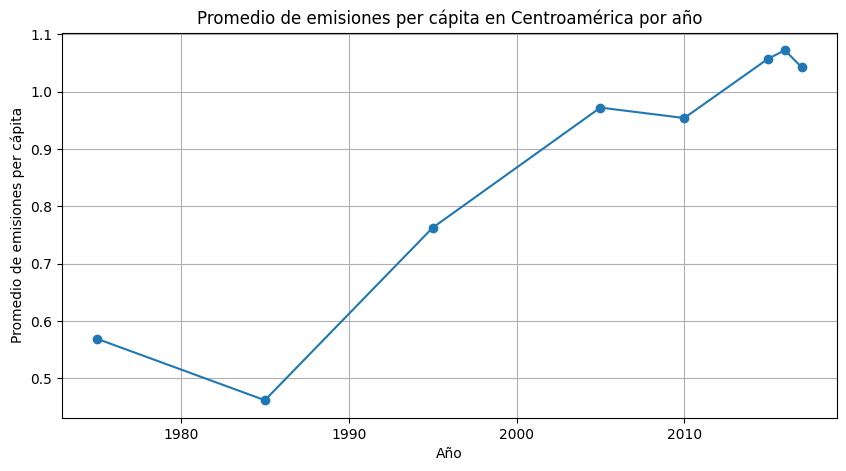

In [154]:
# 5.1 Construye aquí el gráfico de líneas
plt.figure(figsize=(10, 5))
plt.plot(
    reporte_promedio_centroamerica["anio"],
    reporte_promedio_centroamerica["promedio_por_anio"],
    marker="o"
)
plt.title("Promedio de emisiones per cápita en Centroamérica por año")
plt.xlabel("Año")
plt.ylabel("Promedio de emisiones per cápita")
plt.grid(True)
plt.show()

### Lectura del gráfico 1
👤
Elegí una gráfica de líneas porque permite ver la evolución del promedio per cápita en el tiempo y facilita identificar tendencias, aumentos o disminuciones por año.


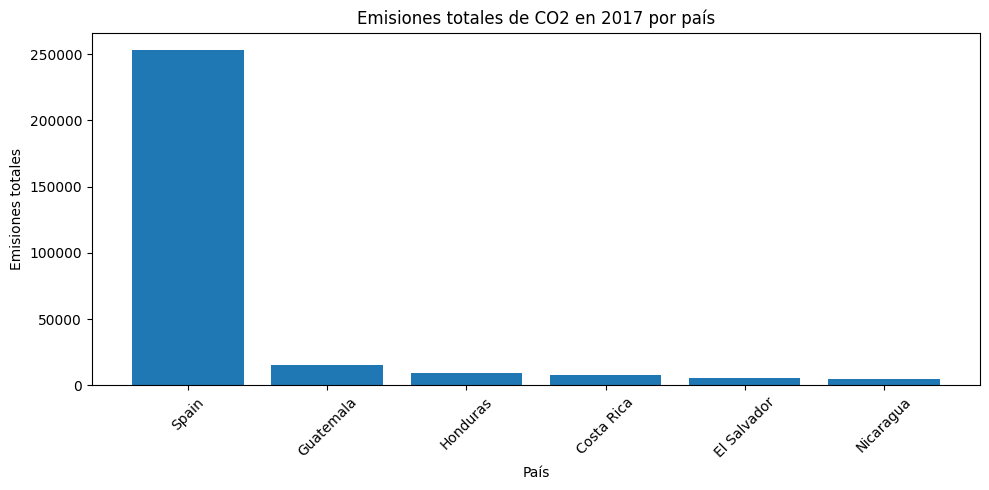

In [155]:
# 5.2 Construye aquí el gráfico de barras comparativo
plt.figure(figsize=(10, 5))
plt.bar(comparacion_2017["pais"], comparacion_2017["valor"])
plt.title("Emisiones totales de CO2 en 2017 por país")
plt.xlabel("País")
plt.ylabel("Emisiones totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Lectura del gráfico 2
👤
Elegí un gráfico de barras porque compara claramente países en un mismo año y permite observar cuál tuvo mayor o menor emisión total en 2017.

### Interpretación de gráficos del Bloque 5
📈📉
Los gráficos muestran dos perspectivas diferentes del problema de emisiones.  
La línea resume cómo cambia el promedio per cápita de Centroamérica a través de los años.  
Las barras comparan la magnitud total de emisiones en 2017 entre países seleccionados.  
En conjunto, ayudan a evitar confundir tendencia promedio por habitante con volumen total emitido por cada país.


---
## Bloque 6 — Informe final crítico (20 pts)

### Objetivo
Cerrar el examen con una síntesis crítica basada en evidencia, no solo con una lista de resultados.

### Debes redactar un informe de 6 a 8 líneas que incluya obligatoriamente
- **2 hallazgos numéricos concretos**
- **1 limitación real del análisis**
- **1 comparación explícita entre emisiones totales y per cápita**
- **1 conclusión final** sobre el comportamiento de las emisiones en los países analizados
- **1 recomendación o advertencia final** basada en tus datos
- **coherencia clara** entre lo que exploraste, calculaste, graficaste y concluiste

### Regla importante
No describas solo resultados: explica qué significan.

### Nivel esperado
- **No logrado:** texto genérico sin cifras ni juicio analítico.
- **Inicial:** incluye alguna cifra, pero la conclusión es débil o desconectada.
- **Intermedio:** presenta hallazgos, limitación y conclusión coherente.
- **Logrado:** sintetiza, compara, limita e interpreta con evidencia concreta y criterio, y además propone una recomendación o advertencia defendible.


### Informe final crítico
🌡️🌎
El análisis muestra que el valor máximo global de emisiones totales pertenece a China, con un valor aproximado de 9,257,933.9 kilotoneladas.
En Costa Rica, el año con mayor emisión total fue 2010, con un valor cercano a 34,533.55 kilotoneladas, según los registros filtrados con Python base.
Una comparación importante es que las emisiones totales y las emisiones per cápita no significan lo mismo: la primera mide la magnitud nacional y la segunda el promedio por habitante, como por ejemplo 5.30 toneladas per cápita en 2005 en Centroamérica.
Una limitación del análisis es que el dataset llega hasta 2017, por lo que no permite concluir sobre cambios recientes.
Además, el análisis no incorpora variables como población exacta, tipo de industria o políticas ambientales de cada país.
La conclusión principal es que las emisiones deben analizarse separando correctamente la métrica usada.
Como recomendación, cualquier decisión o comparación ambiental debe indicar si se habla de emisiones totales o per cápita para evitar interpretaciones equivocadas.


---
## Criterios de corrección visibles para el estudiante
- Se descontarán puntos si usas nombres distintos a los exigidos y eso dificulta la revisión.
- Se descontarán puntos si respondes con texto sin evidencia numérica.
- Se descontarán puntos si usas `pandas` para resolver lo que se pidió explícitamente con Python base.
- Se descontarán puntos si confundes emisiones totales con emisiones per cápita.
- Se descontarán puntos si generas gráficos sin título o sin ejes rotulados.
- Se reconocerá crédito parcial cuando el razonamiento sea correcto aunque el resultado final no sea exacto.
- Se valorará especialmente la coherencia entre exploración, análisis, gráficos e informe final.


## Checklist final de entrega
- [ ] Cargué y exploré el archivo correctamente.
- [ ] Expliqué qué representa una fila del dataset.
- [ ] Expliqué la diferencia entre emisiones totales y per cápita.
- [ ] Creé `df_trabajo`.
- [ ] Creé `df_totales_es` y `df_per_capita_es`.
- [ ] Creé `renombrar_columnas_es(df)` y `separar_por_tipo(df, tipo_emision)`.
- [ ] Escribí una `prediccion_inicial`.
- [ ] Creé `registros_totales`.
- [ ] Creé `resumen_pais(registros, pais)`.
- [ ] Construí `reporte_centroamerica_base`.
- [ ] Comparé mi predicción con la evidencia.
- [ ] Construí `reporte_total_centroamerica`.
- [ ] Construí `reporte_promedio_centroamerica`.
- [ ] Construí `conversiones_costa_rica`.
- [ ] Creé `comparar_paises(df, paises)`.
- [ ] Construí `comparacion_2017` y la usé como evidencia visible.
- [ ] Contrasté emisiones totales vs per cápita con un ejemplo concreto.
- [ ] Generé los 2 gráficos.
- [ ] Expliqué por qué cada gráfico era útil.
- [ ] Escribí el informe final crítico con recomendación o advertencia.
